# Capítulo 5 — Teoria do Funcional da Densidade: Corrigindo o *Gap*

**Simulando Qubits com PySCF** · Cristiano Alves

O Capítulo 4 terminou com um incômodo produtivo: nosso Hartree-Fock reproduziu a **física** do confinamento, mas errou a **quantidade** — *gaps* de 13–17 eV onde o experimento mede 3–4 eV. A culpada tem nome: a **correlação eletrônica**, que o Hartree-Fock ignora por construção.

Neste *notebook* apresentamos a ferramenta que domina a química quântica moderna justamente por incluir a correlação a um custo comparável ao do HF: a **Teoria do Funcional da Densidade**. Ao final, o *gap* terá encolhido — e extrairemos a **densidade de spin** do doador, que abre a Parte II do livro.

> ⏱️ A varredura da Seção 5.6 roda três métodos em quatro tamanhos. É a célula mais lenta; veja a nota antes de executá-la.

In [1]:
# !pip install pyscf matplotlib

## Reaproveitando os capítulos anteriores

As mesmas funções de geometria dos Capítulos 3 e 4.

In [2]:
import numpy as np

A_SI, D_SIH, CORTE = 5.431, 1.48, 2.6

def rede_diamante(n_celulas):
    base = np.array([[0, 0, 0], [.25, .25, .25], [0, .5, .5], [.25, .75, .75],
                     [.5, 0, .5], [.75, .25, .75], [.5, .5, 0], [.75, .75, .25]])
    celulas = np.array([[i, j, k] for i in range(n_celulas)
                        for j in range(n_celulas) for k in range(n_celulas)])
    return (celulas[:, None, :] + base[None, :, :]).reshape(-1, 3) * A_SI

def construir_nanocristal(diametro_nm, n_celulas=8, min_viz=2):
    raio = diametro_nm * 10 / 2
    rede = rede_diamante(n_celulas)
    rede = rede - rede.mean(axis=0)
    dentro = np.linalg.norm(rede, axis=1) <= raio
    while True:
        idx = np.where(dentro)[0]
        pos = rede[idx]
        nviz = [np.sum((np.linalg.norm(pos - p, axis=1) > 0.1) &
                       (np.linalg.norm(pos - p, axis=1) < CORTE)) for p in pos]
        ruins = idx[np.array(nviz) < min_viz]
        if len(ruins) == 0:
            break
        dentro[ruins] = False
    si = rede[dentro]
    hidrogenios = []
    for p in si:
        d = np.linalg.norm(rede - p, axis=1)
        for j in np.where((d > 0.1) & (d < CORTE))[0]:
            if not dentro[j]:
                hidrogenios.append(p + D_SIH * (rede[j] - p) / d[j])
    return si, np.array(hidrogenios)

def inserir_doador(si):
    return int(np.argmin(np.linalg.norm(si, axis=1)))

def geometria(si, h, idx_p=None):
    """String de atomos pronta para o gto.M (sem cabecalho .xyz)."""
    L = []
    for i, p in enumerate(si):
        L.append("%-2s %10.6f %10.6f %10.6f" % ("P" if i == idx_p else "Si", *p))
    for p in h:
        L.append("%-2s %10.6f %10.6f %10.6f" % ("H", *p))
    return "\n".join(L)

print("funcoes carregadas")

funcoes carregadas


## 5.1 Por que o Hartree-Fock não basta

O pecado original do Hartree-Fock: ele descreve cada elétron movendo-se no **campo médio** dos outros, como se a nuvem eletrônica fosse um borrão estático. A realidade é mais sutil — os elétrons executam uma dança coordenada, e essa correlação instantânea **abaixa** a energia. A diferença é, por definição, a **energia de correlação**:

$$E_{\text{corr}} = E_{\text{exata}} - E_{\text{HF}} < 0.$$

Em módulo, ela costuma valer ~1 % da energia total — mas é justamente essa fração que governa energias de ligação, barreiras de reação e, no nosso caso, o *gap*.

> 💡 **Duas rotas para a correlação.** Os métodos *pós-Hartree-Fock* (MP2, *Coupled Cluster*, CI) corrigem a função de onda sistematicamente — precisos e caríssimos, com custos $N^5$, $N^6$ ou pior. Impensáveis para um nanocristal. A segunda rota, que seguiremos, é a DFT: abandona a função de onda como objeto central e reformula tudo em torno da **densidade eletrônica**, com precisão comparável a um custo próximo ao do próprio HF.

## 5.2 Da função de onda à densidade

A função de onda de $N$ elétrons depende de $3N$ coordenadas — para o nosso nanocristal, milhares de variáveis. A DFT nasce de uma percepção revolucionária (**Hohenberg e Kohn**, 1964): toda a informação do estado fundamental está contida na **densidade eletrônica** $\rho(\mathbf{r})$, que depende de apenas **três** coordenadas, não importa quantos elétrons existam.

1. A energia do estado fundamental é um **funcional único** da densidade, $E = E[\rho]$.
2. Esse funcional atinge o mínimo na densidade verdadeira — um princípio variacional.

> 💡 **Funcional?** Uma *função* recebe um número e devolve um número. Um **funcional** recebe uma *função inteira* e devolve um número. A notação $E[\rho]$, com colchetes, sinaliza a distinção.

## 5.3 As equações de Kohn-Sham

Os teoremas garantem a *existência* do funcional, mas não sua *forma* — ninguém conhece a energia cinética exata em termos só de $\rho$. Em 1965, **Kohn e Sham** deram o passo decisivo: introduziram um sistema auxiliar de elétrons **não interagentes** com **exatamente a mesma densidade**. Nele, a energia cinética se calcula trivialmente, e os orbitais obedecem a

$$\left[ -\tfrac{1}{2}\nabla^2 + v_{\text{ext}} + v_{\text{H}}[\rho] + v_{\text{xc}}[\rho] \right] \psi_i = \varepsilon_i\,\psi_i.$$

Os três primeiros termos são exatos. **Toda a nossa ignorância foi empurrada para $v_{\text{xc}}$**, o potencial de troca e correlação.

> 💡 **A analogia com o SCF.** Essa equação é estruturalmente idêntica às equações de Roothaan-Hall do Capítulo 4: um problema de autovalores em que o operador depende da densidade, que depende dos orbitais. Resolve-se pelo **mesmo ciclo SCF**. Por isso, no PySCF, migrar de HF para DFT custa **uma linha**.

> ⚠️ **A DFT é exata — na teoria.** As equações de Kohn-Sham seriam exatas se conhecêssemos o $E_{\text{xc}}[\rho]$ verdadeiro. Como não conhecemos, toda DFT prática usa uma **aproximação**. Ao contrário do *Coupled Cluster*, a DFT não pode ser sistematicamente melhorada: escolher um funcional é arte guiada por física e validação.

## 5.4 A escada de Jacob

As aproximações para $E_{\text{xc}}$ organizam-se em degraus (metáfora de John Perdew), cada um usando mais informação sobre a densidade:

| Degrau | Ingrediente | Exemplo | Custo |
|---|---|---|---|
| LDA | $\rho$ | SVWN | baixo |
| GGA | $\rho, \nabla\rho$ | **PBE** | baixo |
| meta-GGA | $+\,\tau$ (energia cinética) | SCAN | médio |
| Híbrido | $+$ troca exata de HF | **B3LYP**, PBE0 | alto |

> 💡 **Qual escolher?** Para uma estimativa rápida e robusta, **PBE** (sem parâmetros ajustados). Quando o alvo é o *gap*, suba um degrau e use um híbrido como **B3LYP**. Compararemos os dois.

## 5.5 DFT no PySCF: o módulo `dft`

A promessa se cumpre: troca-se `scf` por `dft` e informa-se o funcional em `.xc`. Todo o resto é idêntico.

In [3]:
from pyscf import gto, scf, dft

mol_h2 = gto.M(atom="H 0 0 0; H 0 0 0.74", basis="sto-3g", verbose=0)

hf = scf.RHF(mol_h2); hf.kernel()
ks = dft.RKS(mol_h2); ks.xc = "pbe"; ks.kernel()

print("H2 / STO-3G")
print("  Hartree-Fock : %.6f Ha" % hf.e_tot)
print("  DFT (PBE)    : %.6f Ha" % ks.e_tot)
print("  diferenca    : %.6f Ha" % (ks.e_tot - hf.e_tot))

H2 / STO-3G
  Hartree-Fock : -1.116759 Ha
  DFT (PBE)    : -1.152073 Ha
  diferenca    : -0.035313 Ha


A correspondência entre os métodos é direta:

| Camada | Hartree-Fock | Kohn-Sham (DFT) |
|---|---|---|
| Fechada (`spin=0`) | `scf.RHF` | `dft.RKS` |
| Aberta, restrita | `scf.ROHF` | `dft.ROKS` |
| Aberta, irrestrita | `scf.UHF` | `dft.UKS` |

### A malha de integração

Há uma diferença conceitual: o termo $E_{\text{xc}}$ **não** pode ser integrado analiticamente. Ele é avaliado **numericamente**, sobre uma malha de pontos em torno de cada átomo.

In [4]:
import time

print("nivel  E(PBE) [Ha]        tempo")
for nivel in [0, 1, 3, 5]:
    t = time.time()
    mf = dft.RKS(mol_h2); mf.xc = "pbe"; mf.grids.level = nivel
    mf.kernel()
    print("  %d    %14.8f   %.2f s" % (nivel, mf.e_tot, time.time() - t))

nivel  E(PBE) [Ha]        tempo
  0       -1.15102165   0.14 s
  1       -1.15207386   0.04 s


  3       -1.15207280   0.58 s


  5       -1.15207280   0.62 s


> ⚠️ **A malha pode trair você.** Uma malha grosseira introduz ruído numérico na energia, chegando a impedir a convergência do SCF ou a produzir diferenças de energia sem sentido físico. O padrão `grids.level = 3` serve para a maioria dos casos; se um cálculo DFT oscilar ou der energias irreprodutíveis, **aumente a malha** antes de suspeitar de qualquer outra coisa.

> 💡 Os nomes de funcionais são *strings* e cobrem centenas de opções via **Libxc**: `'lda'`, `'pbe'`, `'b3lyp'`, `'pbe0'`, `'scan'`. Consulte `dft.libxc.XC_CODES` para a lista completa.

## 5.6 Mãos à Obra: Hartree-Fock *versus* DFT no *gap*

Chegou a hora de saldar a dívida do Capítulo 4. Vamos recalcular o *gap* dos mesmos nanocristais, agora com PBE e B3LYP. A previsão: a correlação deve **fechar** o *gap* inflado do HF.

> ⏱️ **A célula abaixo é a mais lenta do notebook** — três métodos em quatro tamanhos, e o B3LYP custa mais que o PBE por reintroduzir a troca exata. Para um teste rápido, remova o `1.2` da lista.

In [5]:
HARTREE_EV = 27.2114

def gap_homo_lumo(mf):
    """Gap HOMO-LUMO (eV) de um calculo de camada fechada convergido."""
    assert mf.converged, "SCF nao convergiu!"
    no = int(mf.mo_occ.sum() // 2)
    return (mf.mo_energy[no] - mf.mo_energy[no - 1]) * HARTREE_EV

def calcula_gaps(diametro):
    """Gap do nanocristal de Si:H por HF, PBE e B3LYP."""
    si, h = construir_nanocristal(diametro)
    mol = gto.M(atom=geometria(si, h), basis="sto-3g", verbose=0)

    resultados = []
    for nome in ["hf", "pbe", "b3lyp"]:
        mf = scf.RHF(mol) if nome == "hf" else dft.RKS(mol)
        if nome != "hf":
            mf.xc = nome
        mf.kernel()
        resultados.append(gap_homo_lumo(mf))
    return mol.nao, resultados

diametros = [0.8, 0.9, 1.0, 1.2]
tabela = []
print("  D(nm)   nao      HF     PBE   B3LYP")
for d in diametros:
    t = time.time()
    nao, (g_hf, g_pbe, g_b3) = calcula_gaps(d)
    tabela.append([g_hf, g_pbe, g_b3])
    print("  %4.1f   %4d  %6.2f  %6.2f  %6.2f   (%.0f s)"
          % (d, nao, g_hf, g_pbe, g_b3, time.time() - t), flush=True)
tabela = np.array(tabela)

  D(nm)   nao      HF     PBE   B3LYP


   0.8    106   16.82    8.29    9.86   (39 s)


   0.9    199   14.76    6.77    8.23   (97 s)


   1.0    226   14.61    6.66    8.11   (117 s)


   1.2    364   13.65    5.99    7.37   (672 s)


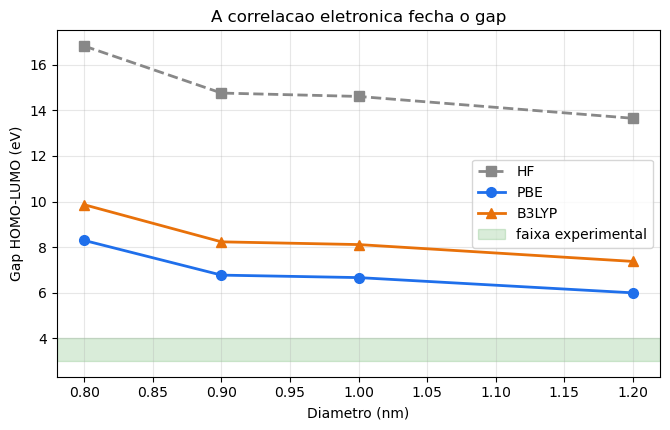

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6.8, 4.4))
for col, nome, marca, cor in zip(range(3), ["HF", "PBE", "B3LYP"],
                                 ["s--", "o-", "^-"], ["#888888", "#1f6feb", "#e8710a"]):
    plt.plot(diametros, tabela[:, col], marca, color=cor, lw=2, ms=7, label=nome)
plt.axhspan(3, 4, alpha=0.15, color="green", label="faixa experimental")
plt.xlabel("Diametro (nm)"); plt.ylabel("Gap HOMO-LUMO (eV)")
plt.title("A correlacao eletronica fecha o gap")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

O resultado é eloquente: a DFT **derruba** o *gap* em relação ao Hartree-Fock, e o B3LYP — que reintroduz 20 % da troca exata — situa-se **entre** os dois extremos, exatamente como a teoria previa: mais troca exata, maior o *gap*.

E, crucialmente, os três métodos **preservam a tendência** do confinamento: o *gap* cai monotonicamente com o tamanho em todos eles. A física estava certa desde o Capítulo 4; a DFT ajustou a escala.

> ⚠️ **O *gap* de Kohn-Sham não é o *gap* óptico.** Reduzimos a superestimativa do HF, mas o leitor rigoroso deve saber: a diferença $\varepsilon_{\text{LUMO}} - \varepsilon_{\text{HOMO}}$ dos orbitais de Kohn-Sham é uma grandeza **do estado fundamental**, e não corresponde exatamente à energia de uma excitação óptica real (que envolve também a atração entre o elétron excitado e o buraco). O *gap* óptico rigoroso exige **TDDFT**. Some-se a isso a base mínima STO-3G, que ainda infla os virtuais. Nosso objetivo aqui é mais modesto e legítimo: mostrar que a **correlação move os números na direção certa**.

## 🔷 Projeto Âncora — Etapa 2: a densidade de spin do doador

Com a DFT em mãos, revisitamos o sistema Si:P — desta vez com camada aberta **irrestrita** (`dft.UKS`), o método que dá a cada spin sua própria densidade e, por isso, acessa diretamente a grandeza que definirá o *qubit*: a **densidade de spin**

$$\rho_s(\mathbf{r}) = \rho_\uparrow(\mathbf{r}) - \rho_\downarrow(\mathbf{r}),$$

a assinatura espacial do elétron desemparelhado.

In [7]:
si, h = construir_nanocristal(1.0)
idx_p = inserir_doador(si)
mol = gto.M(atom=geometria(si, h, idx_p), basis="sto-3g", spin=1, verbose=0)

mf = dft.UKS(mol); mf.xc = "pbe"
mf.kernel()
assert mf.converged

# densidade de spin projetada em cada atomo (analise de Mulliken)
dm_a, dm_b = mf.make_rdm1()                       # matrizes de densidade alfa e beta
S = mol.intor("int1e_ovlp")
spin_ao = np.einsum("ij,ji->i", dm_a - dm_b, S)   # spin liquido por funcao de base
fatias = mol.aoslice_by_atom()
spin_atomo = np.array([spin_ao[a[2]:a[3]].sum() for a in fatias])

iP = [mol.atom_symbol(i) for i in range(mol.natm)].index("P")
dist = np.linalg.norm(mol.atom_coords() - mol.atom_coords()[iP], axis=1) * 0.529177

print("Sistema: %d eletrons | %d funcoes de base | spin = %d"
      % (mol.nelectron, mol.nao, mol.spin))
print("Spin total integrado:            %.2f" % spin_atomo.sum())
print("Densidade de spin sobre o P:     %.0f%%" % (100 * spin_atomo[iP]))
print("Densidade de spin ate 3 A do P:  %.0f%%" % (100 * spin_atomo[dist < 3].sum()))
print("Densidade de spin ate 5 A do P:  %.0f%%" % (100 * spin_atomo[dist < 5].sum()))

Sistema: 337 eletrons | 226 funcoes de base | spin = 1
Spin total integrado:            1.00
Densidade de spin sobre o P:     12%
Densidade de spin ate 3 A do P:  80%
Densidade de spin ate 5 A do P:  92%


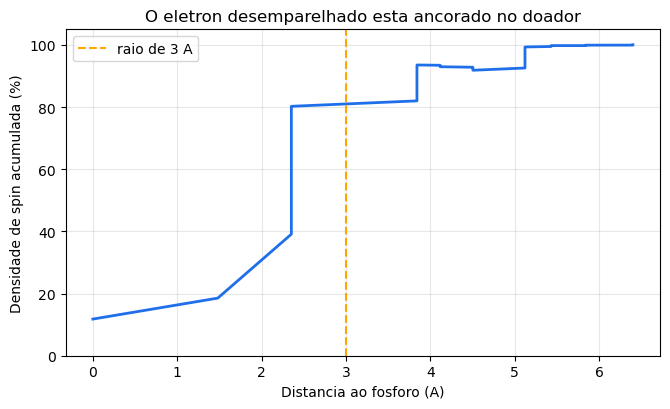

In [8]:
# Como a densidade de spin se distribui com a distancia ao fosforo
ordem = np.argsort(dist)
acum = np.cumsum(spin_atomo[ordem]) * 100

plt.figure(figsize=(6.8, 4.2))
plt.plot(dist[ordem], acum, lw=2, color="#1f6feb")
plt.axvline(3, ls="--", c="orange", label="raio de 3 A")
plt.xlabel("Distancia ao fosforo (A)")
plt.ylabel("Densidade de spin acumulada (%)")
plt.title("O eletron desemparelhado esta ancorado no doador")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 105)
plt.tight_layout(); plt.show()

**A física do *qubit*, agora em cores de spin.** O spin líquido integra a exatamente **1** — há um, e apenas um, elétron desemparelhado, como manda a contagem ímpar do Capítulo 3. E ele não está espalhado: a maior parte da densidade de spin concentra-se num raio de 3 Å em torno do fósforo, corroborando com um método correlacionado o que o SOMO de Hartree-Fock já sugerira.

**Por que a densidade de spin é o próximo tesouro.** É a densidade de spin **no próprio núcleo** de $^{31}$P que determina o **acoplamento hiperfino de contato de Fermi** — o diálogo entre o spin do elétron (nosso *qubit*) e o spin do núcleo, e um dos parâmetros mais importantes de um *qubit* de spin em silício. Acabamos de calcular o objeto de onde esse acoplamento brota. A Parte II se dedicará a extraí-lo.

## Exercícios

Resolva nas células abaixo.

**5.1 HF é DFT?** Explique, em duas ou três frases, por que o Hartree-Fock pode ser visto como um caso particular das equações de Kohn-Sham. Qual termo de $E_{\text{xc}}$ ele inclui e qual ele omite?

**5.2 O efeito do funcional.** Para o nanocristal de 0,8 nm, calcule o *gap* com `'lda'`, `'pbe'` e `'pbe0'`. Ordene os funcionais pelo *gap* e relacione a ordem à fração de troca exata de cada um.

**5.3 A malha importa.** Rode o nanocristal de 0,9 nm com PBE variando `mf.grids.level` de 1 a 5. A partir de qual nível a energia estabiliza (varia menos de $10^{-4}$ Ha)?

**5.4 Correlação em números.** Para o nanocristal de 0,8 nm, calcule a energia total em HF e em PBE. Que fração da energia total representa a diferença? Confere com o "~1 %" do texto?

**5.5 Restrito vs. irrestrito.** Repita o cálculo do doador com `dft.ROKS` e `dft.UKS` (ambos PBE). Compare a energia e `mf.spin_square()`. O UKS sofre contaminação de spin? Quanto $\langle S^2\rangle$ deveria valer para um dubleto?

**5.6 Projeto Âncora.** Refaça a Etapa 2 trocando PBE por B3LYP. A densidade de spin sobre o fósforo muda muito? O que isso sugere sobre a robustez da localização do *qubit* frente à escolha do funcional?

In [9]:
# 5.2 Efeito do funcional (lda, pbe, pbe0)

In [10]:
# 5.4 Correlacao em numeros

In [11]:
# 5.5 ROKS vs UKS e contaminacao de spin

In [12]:
# 5.6 Projeto Ancora com B3LYP